# DL080 微分方程与可微模拟基础

对应S3。按顺序执行；先预测结果再看输出。数据和研究范围见lecture.md。本Notebook实际复跑全部实验，写入notebook_outputs，不覆盖课程参考输出。

In [1]:
from pathlib import Path
import json, sys
# Notebook应在本单元目录启动。
print("Python",sys.version.split()[0])
print("目录",Path.cwd())
if not Path("experiment.py").exists():
    raise RuntimeError("请在当前单元目录运行")

Python 3.12.14
目录 /workspace/scratch/1577d0a62398/course-batch-078-082/dl/units/080


## 先运行数值与边界测试
测试通过不等于科学假设成立，但失败时不要跳过。

In [2]:
import unittest
import test_experiment
# 使用显式unittest检查，不依赖可被-O移除的assert。
suite=unittest.defaultTestLoader.loadTestsFromModule(test_experiment)
result=unittest.TextTestRunner(verbosity=2).run(suite)
if not result.wasSuccessful():
    raise RuntimeError("测试失败，停止实验")

test_autodiff_shared_parameter (test_experiment.Tests.test_autodiff_shared_parameter) ... 

ok


test_autodiff_solver (test_experiment.Tests.test_autodiff_solver) ... 

ok


test_closed_discrete (test_experiment.Tests.test_closed_discrete) ... 

...

test_rk4 (test_experiment.Tests.test_rk4) ... 

ok


test_zero_rate (test_experiment.Tests.test_zero_rate) ... 

ok


----------------------------------------------------------------------
Ran 15 tests in 0.049s

OK


## 完整复跑
参数、预测和数据都由本次运行重新生成；运行时长取决于机器。

In [3]:
from experiment import run
results=run("notebook_outputs")
print(json.dumps(results,ensure_ascii=False,indent=2))

{
  "k_true": 1.0,
  "y0": 2.0,
  "T": 2.0,
  "observed_terminal": 0.2706705664732254,
  "scan_columns": [
    "n",
    "dt",
    "euler_state_error",
    "euler_gradient_error",
    "rk4_state_error",
    "finite_difference_error",
    "reverse_error"
  ],
  "scan": [
    [
      4,
      0.5,
      0.1456705664732254,
      0.04134113294645081,
      0.00042897454113394184,
      6.438849453616058e-12,
      0.0
    ],
    [
      8,
      0.25,
      0.0704447363951004,
      0.007405586071450809,
      2.171744103968143e-05,
      2.5843327478014544e-11,
      0.0
    ],
    [
      16,
      0.125,
      0.034536392430727814,
      0.0016058779921706012,
      1.222465512762394e-06,
      7.59037277475727e-12,
      0.0
    ],
    [
      32,
      0.0625,
      0.017092993719224736,
      0.00037564440458259796,
      7.251806105612602e-08,
      5.383604673170339e-11,
      0.0
    ],
    [
      64,
      0.03125,
      0.008502501516275296,
      9.0934325650327e-05,
      4.4

## 同一离散程序的三种导数

In [4]:
import numpy as np
from experiment import euler, reverse_gradient, exact, autodiff_euler
k,y0,T,n = 1.,2.,2.,20
_,y,s = euler(k,y0,T,n)
eps=1e-6
gfd=(euler(k+eps,y0,T,n)[1][-1]-euler(k-eps,y0,T,n)[1][-1])/(2*eps)
print("前向、反向、差分",s[-1],reverse_gradient(k,y0,T,n),gfd)
print("自动微分",autodiff_euler(k,y0,T,n))
print("连续导数",-T*exact(k,y0,T))

前向、反向、差分 -0.5403406870691969 -0.540340687069197 -0.5403406870552185
自动微分 (0.24315330918113856, -0.5403406870691969)
连续导数 -0.5413411329464508


## 检查偶然的首阶抵消

In [5]:
for T in [1.,2.]:
    errors=[]
    for n in [16,32,64,128,256]:
        # 相对于连续解析导数，不是相对于同一个离散差分。
        g=euler(1.,2.,T,n)[2][-1]
        errors.append(abs(g+T*exact(1.,2.,T)))
    print("T",T,"误差",errors,"相邻比",np.array(errors[:-1])/errors[1:])

T 1.0 误差 [np.float64(0.02386592928760667), np.float64(0.011710101928220862), np.float64(0.005801039930451557), np.float64(0.002887222192875183), np.float64(0.001440311792278548)] 相邻比 [2.03806333 2.01862116 2.00921146 2.00458137]
T 2.0 误差 [np.float64(0.0016058779921706012), np.float64(0.00037564440458259796), np.float64(9.0934325650327e-05), np.float64(2.2375848196531933e-05), np.float64(5.550104862361849e-06)] 相邻比 [4.27499511 4.13094177 4.06394988 4.03160819]


## PDE稳定参数和边界

In [6]:
from experiment import heat_explicit
x=np.linspace(0,1,41); dx=x[1]-x[0]; alpha=.1
dt=.4*dx*dx/alpha
u=heat_explicit(np.sin(np.pi*x),alpha,dx,dt,100)
print("dt / 总时间 / 边界",dt,100*dt,u[0],u[-1])
try:
    heat_explicit(np.sin(np.pi*x),alpha,dx,.6*dx*dx/alpha,100)
except ValueError as error:
    print("预期拒绝不稳定参数:",error)

dt / 总时间 / 边界 0.0025000000000000005 0.25000000000000006 0.0 0.0
预期拒绝不稳定参数: explicit heat step violates mu<=1/2


## 阅读输出与研究边界
下面显示课程参考图；数值来自本次复跑results，两者的来源请分清。最后用自己的话回答实验册的限制问题。

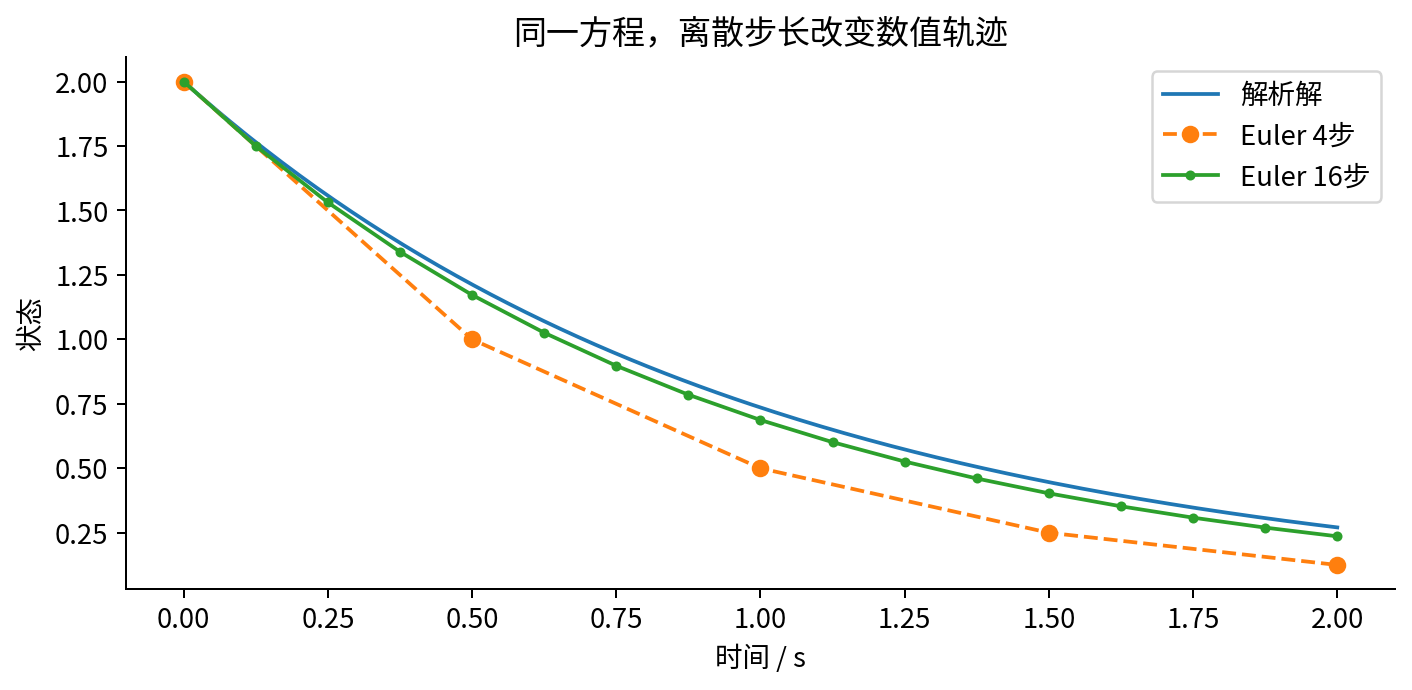

In [7]:
from IPython.display import display, Image
# 图由课程参考outputs重建，这里核验Notebook图像显示。
figure=sorted(Path("figures").glob("*.png"))[0]
display(Image(filename=str(figure),width=640))